# Customer Churn Prediction - Feature Engineering & Model Building

## Objective

In this notebook, we will:

- Load the cleaned dataset
- Separate features and target
- Encode categorical variables
- Split the dataset
- Train machine learning models
- Evaluate model performance

Import Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

Load the Dataset

In [2]:
df = pd.read_csv("../data/processed/cleaned_customer_churn.csv")

Display the Dataset

In [3]:
df.head()

,customer_id,age_group,gender,region,customer_segment,preferred_channel,purchase_frequency,avg_order_value,total_spent,recency_days,website_visits,discount_usage_rate,email_open_rate,cart_abandonment_rate,loyalty_score,engagement_score,churn_risk,churn_flag
0,C000001,18-24,Other,North,Loyal,Online,5,381.27,2108.80,189,27,0.38,0.13,0.42,33,35.5,Medium,1
1,C000002,25-34,Other,South,New,Mobile App,12,376.65,3843.06,277,68,0.51,0.06,0.07,68,49.5,Medium,1
2,C000003,55+,Other,North,VIP,Online,5,37.73,224.65,271,23,0.64,0.22,0.46,73,38.0,High,1
3,C000004,18-24,Male,North,Returning,Mobile App,12,191.19,1960.79,89,93,0.66,0.31,0.13,93,59.0,Low,0
4,C000005,55+,Other,North,Returning,Mobile App,2,279.64,594.79,264,4,0.73,0.27,0.58,11,34.5,High,1


Separate Features and Target

In [4]:
df["churn_flag"].value_counts()

churn_flag
0    53776
1    46224
Name: count, dtype: int64

In [5]:
X = df.drop("churn_flag", axis=1)

y = df["churn_flag"]

Remove Customer ID

In [6]:
X = X.drop("customer_id", axis=1)

Check Categorical Columns

In [7]:
X.select_dtypes(include="object").columns

Index(['age_group', 'gender', 'region', 'customer_segment',
       'preferred_channel', 'churn_risk'],
      dtype='object')

Encode Categorical Columns

In [43]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Identify categorical and numerical columns
categorical_features = X.select_dtypes(include=["object"]).columns

numerical_features = X.select_dtypes(exclude=["object"]).columns

# Create the preprocessing transformer
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numerical_features)
    ]
)

In [9]:
X.head()

,age_group,gender,region,customer_segment,preferred_channel,purchase_frequency,avg_order_value,total_spent,recency_days,website_visits,discount_usage_rate,email_open_rate,cart_abandonment_rate,loyalty_score,engagement_score,churn_risk
0,0,2,2,0,2,5,381.27,2108.80,189,27,0.38,0.13,0.42,33,35.5,2
1,1,2,3,1,1,12,376.65,3843.06,277,68,0.51,0.06,0.07,68,49.5,2
2,4,2,2,3,2,5,37.73,224.65,271,23,0.64,0.22,0.46,73,38.0,0
3,0,1,2,2,1,12,191.19,1960.79,89,93,0.66,0.31,0.13,93,59.0,1
4,4,2,2,2,1,2,279.64,594.79,264,4,0.73,0.27,0.58,11,34.5,0


Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
print(X_train.shape)
print(X_test.shape)

(80000, 16)
(20000, 16)


Train Logistic Regression

In [12]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

c:\customer_churn_prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

Predict

In [13]:
y_pred = lr.predict(X_test)

Evaluate

In [14]:
print("Accuracy :", accuracy_score(y_test, y_pred))

Accuracy : 0.93405


More Metrics

In [15]:
print("Precision :", precision_score(y_test, y_pred))

print("Recall :", recall_score(y_test, y_pred))

print("F1 Score :", f1_score(y_test, y_pred))

Precision : 0.9335886214442013
Recall : 0.9229853975121688
F1 Score : 0.9282567310307316


Classification Report

In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.94      0.94     10755
           1       0.93      0.92      0.93      9245

    accuracy                           0.93     20000
   macro avg       0.93      0.93      0.93     20000
weighted avg       0.93      0.93      0.93     20000



Confusion Matrix

In [17]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[10148   607]
 [  712  8533]]


Train Decision Tree

In [18]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy :", accuracy_score(y_test, dt_pred))

Decision Tree Accuracy : 0.9186


Train Random Forest

In [19]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy :", accuracy_score(y_test, rf_pred))

Random Forest Accuracy : 0.9446


Compare Models

In [20]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.93405
1,Decision Tree,0.91860
2,Random Forest,0.94460


Create the Random Forest Pipeline

In [45]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy :", accuracy_score(y_test, rf_pred))

Random Forest Accuracy : 0.9446


In [46]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            random_state=42
        ))
    ]
)

Import Pipeline

In [44]:
from sklearn.pipeline import Pipeline

In [47]:
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['age_group','gender','region',...,'loyalty_score','engagement_score', 'churn_risk']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

In [48]:
rf_pred = rf_pipeline.predict(X_test)

In [49]:
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.9446


In [50]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95     10755
           1       0.94      0.94      0.94      9245

    accuracy                           0.94     20000
   macro avg       0.94      0.94      0.94     20000
weighted avg       0.94      0.94      0.94     20000



Select the Best Model

In [21]:
best_model = rf

Save the Model

In [22]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.


In [23]:
import joblib

joblib.dump(best_model, "../models/churn_model.pkl")

['../models/churn_model.pkl']

In [24]:
import os

os.listdir("../models")

['churn_model.pkl']

Evaluate Logistic Regression

In [25]:
print("Logistic Regression Results")
print("-" * 40)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Logistic Regression Results
----------------------------------------
Accuracy : 0.93405
Precision: 0.9335886214442013
Recall   : 0.9229853975121688
F1 Score : 0.9282567310307316


Print Classification Report

In [26]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.94      0.94     10755
           1       0.93      0.92      0.93      9245

    accuracy                           0.93     20000
   macro avg       0.93      0.93      0.93     20000
weighted avg       0.93      0.93      0.93     20000



Confusion Matrix

In [27]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[10148   607]
 [  712  8533]]


Plot Confusion Matrix

In [37]:
import matplotlib.pyplot as plt

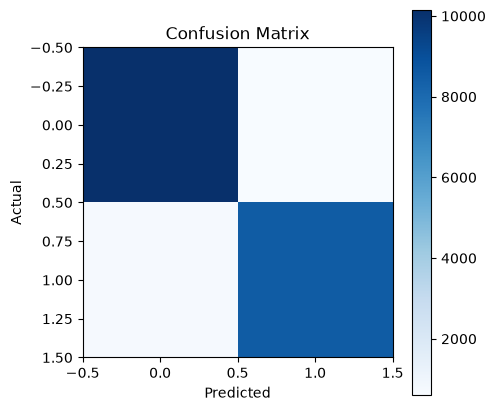

In [38]:
plt.figure(figsize=(5,5))

plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.colorbar()

plt.show()

Evaluate Decision Tree

In [29]:
dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy :", accuracy_score(y_test, dt_pred))

Decision Tree Accuracy : 0.9186


Evaluate Random Forest

In [30]:
rf_pred = rf.predict(X_test)

print("Random Forest Accuracy :", accuracy_score(y_test, rf_pred))

Random Forest Accuracy : 0.9446


Create Comparison Table

In [31]:
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.93405
1,Decision Tree,0.91860
2,Random Forest,0.94460


Find Best Model

In [32]:
best_model = results.loc[
    results["Accuracy"].idxmax()
]

best_model

Model       Random Forest
Accuracy           0.9446
Name: 2, dtype: object

Save the Best Model

In [33]:
import joblib

In [34]:
joblib.dump(rf, "../models/churn_model.pkl")

['../models/churn_model.pkl']

Verify the Model

In [35]:
import os

os.listdir("../models")

['churn_model.pkl']

Save the Scaler

In [39]:
import joblib

joblib.dump(best_model, "../models/churn_model.pkl")

['../models/churn_model.pkl']

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [41]:
joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']

In [42]:
os.listdir("../models")

['churn_model.pkl', 'scaler.pkl']

In [52]:
cm = confusion_matrix(y_test, rf_pred)

print(cm)

[[10224   531]
 [  577  8668]]


In [53]:
import joblib

joblib.dump(rf_pipeline, "../models/churn_pipeline.pkl")

['../models/churn_pipeline.pkl']

In [54]:
import os

print(os.listdir("../models"))

['churn_model.pkl', 'churn_pipeline.pkl', 'scaler.pkl']
